In [ ]:
import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scienceplots
import numpy as np

matplotlib.rc('xtick', labelsize=10) 
matplotlib.rc('ytick', labelsize=10) 

# needs
# pip install SciencePlots
plt.style.use(['science'])

metrics_dir = "./augmented_datasets_metrics"


In [ ]:
headers = ["model", "method", "dataset", "augmentation_rate", "tsed_score"]
all_data = []

for root, _, files in os.walk(metrics_dir):
    if "paraphrase" in root:
        continue

    for file in files:
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(root, file)
        df = pd.read_csv(file_path)

        if df.empty or "augmentation_rate" not in df.columns:
            continue

        df["augmentation_rate"] = df["augmentation_rate"].astype(float)
        # skip all 0.05 steps
        df = df[(df["augmentation_rate"] * 100).astype(int) % 10 == 0]
        df.sort_values("augmentation_rate", inplace=True)

        valid_rates = df["augmentation_rate"].value_counts()
        valid_rates = valid_rates[valid_rates == 5].index
        df = df[df["augmentation_rate"].isin(valid_rates)]
        df = df[df['tsed_score'].notna()]

        if df.empty:
            continue

        for (i, row) in df.iterrows():
            all_data.append([row["model"], row["method"], row["dataset"], row["augmentation_rate"], row["tsed_score"]])

df = pd.DataFrame(all_data, columns=headers)

In [261]:
model_names = {
    "claude": "Claude 3 Haiku",
    "openai": "GPT-4o mini",
    "gemini": "Gemini 2.0 Flash",
    "llama": "Llama 3.3 70B"
}

aug_names = {
    "keyboard": "Keyboard Typos",
    "synonym": "Synonyms",
    "paraphraser": "Paraphrasing"
}

dataset_names = {
    "oldleetcode.json": "LeetCode (Old)",
    "newleetcode.json": "LeetCode (New)",
    "ourdataset.json": "Our Dataset"
}

In [262]:
for model in df["model"].unique().tolist():
    for method in df["method"].unique().tolist():
        mm_df = df[(df["model"] == model) & (df["method"] == method)]
        # print(mm_df.shape)
        stds = mm_df.groupby("augmentation_rate")[["tsed_score"]].std()
        ci = 1.96 * stds["tsed_score"] / len(stds)
        print(f"{model} {method}", (2 * ci).max())


gemini synonym 0.09965058009543205
gemini keyboard 0.10420977364258056
claude synonym 0.08484170961029844
claude keyboard 0.0876664743629174
openai synonym 0.0931076944056192
openai keyboard 0.09272790493744987
llama synonym 0.08451289984708808
llama keyboard 0.08581017007521761


In [ ]:
def plot_with_ci(df_to_show, label):
    means = df_to_show.groupby("augmentation_rate")[["tsed_score"]].mean()
    stds = df_to_show.groupby("augmentation_rate")[["tsed_score"]].std()
    ci = 1.96 * stds["tsed_score"] / len(means)

    plt.fill_between(means.index, means["tsed_score"] - ci, means["tsed_score"] + ci, alpha=0.15)
    plt.plot(means.index, means["tsed_score"], label=label)

def setup_figure(title):
    plt.title(title, fontsize=12)
    plt.xlabel("Augmentation rate", fontsize=10)
    plt.ylabel("Code similarity", fontsize=10)
    plt.ylim(0.0, 1.0)
    plt.legend()
    plt.grid(True)
    fig.tight_layout()


def plot_all_models(df, save_label=None):
    for method in df["method"].unique().tolist():
        fig = plt.figure(figsize=(3.54,3.54), dpi=300)

        for model in df["model"].unique().tolist():
            mm_df = df[(df["model"] == model) & (df["method"] == method)]
            plot_with_ci(mm_df, label=model_names[model])

        setup_figure(aug_names[method])
        if save_label is not None:
            save_path = os.path.join("figures", f"{method}_{save_label}.png")
            plt.savefig(save_path, bbox_inches='tight')
        plt.show()

def plot_all_datasets(df, save_label=None):
    for dataset in df["dataset"].unique().tolist():
        fig = plt.figure(figsize=(3.54,3.54), dpi=300)

        for method in df["method"].unique().tolist():
            dm_df = df[(df["dataset"] == dataset) & (df["method"] == method)]
            plot_with_ci(dm_df, label=aug_names[method])

        setup_figure(dataset_names[dataset])
        if save_label is not None:
            save_path = os.path.join("figures", f"{dataset}_{save_label}.png")
            plt.savefig(save_path, bbox_inches='tight')
        plt.show()

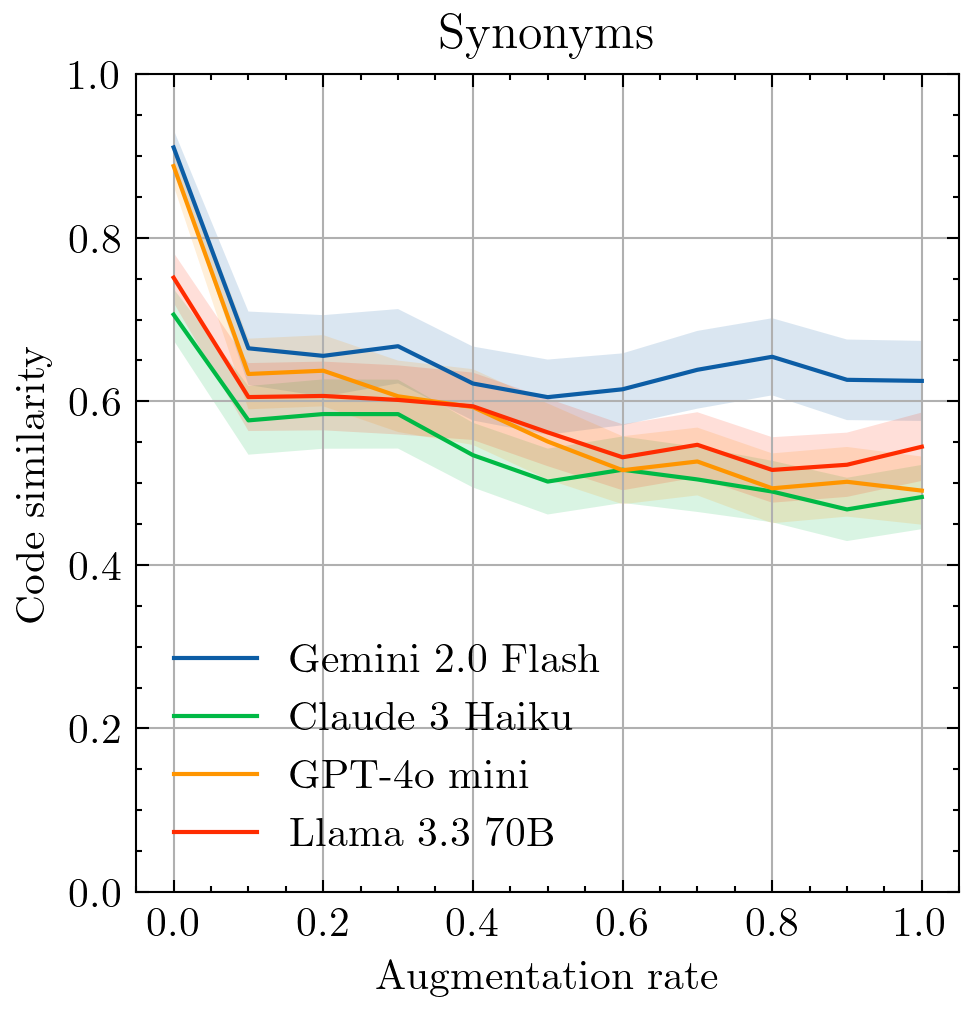

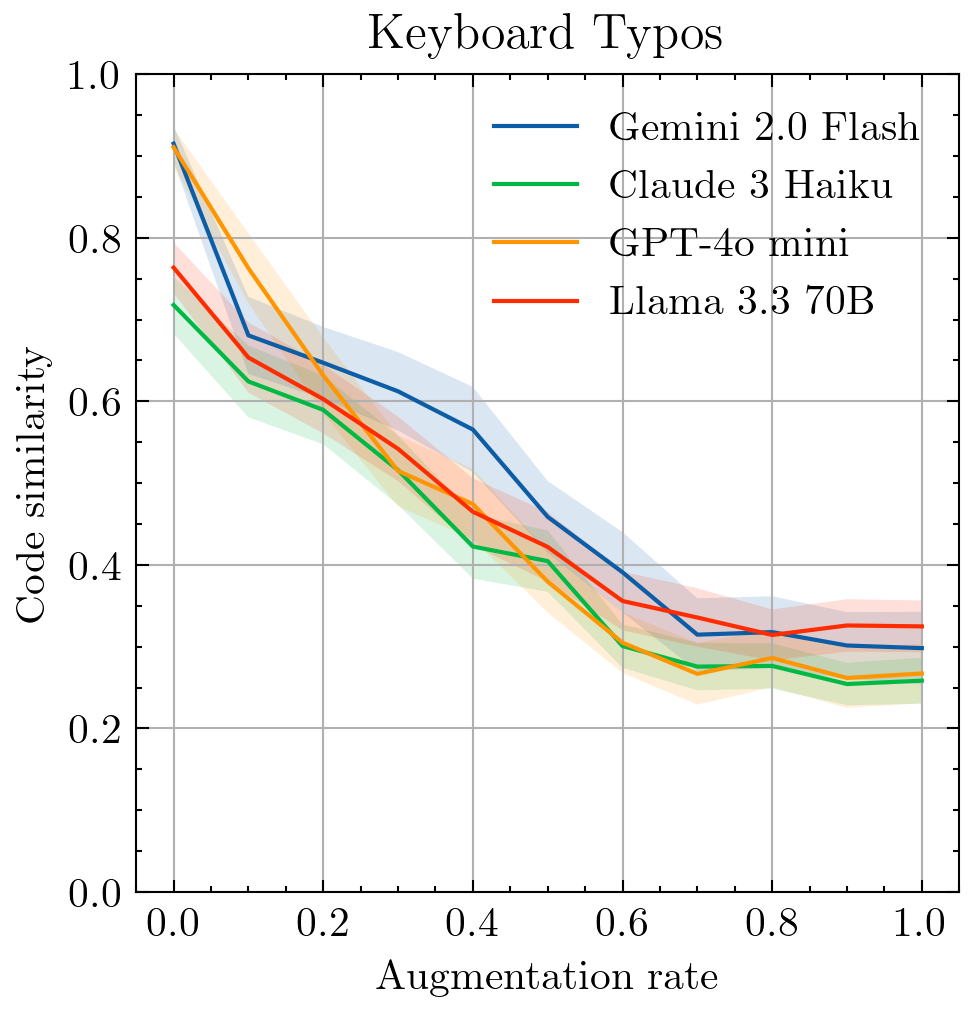

In [264]:
plot_all_models(df, "overall")

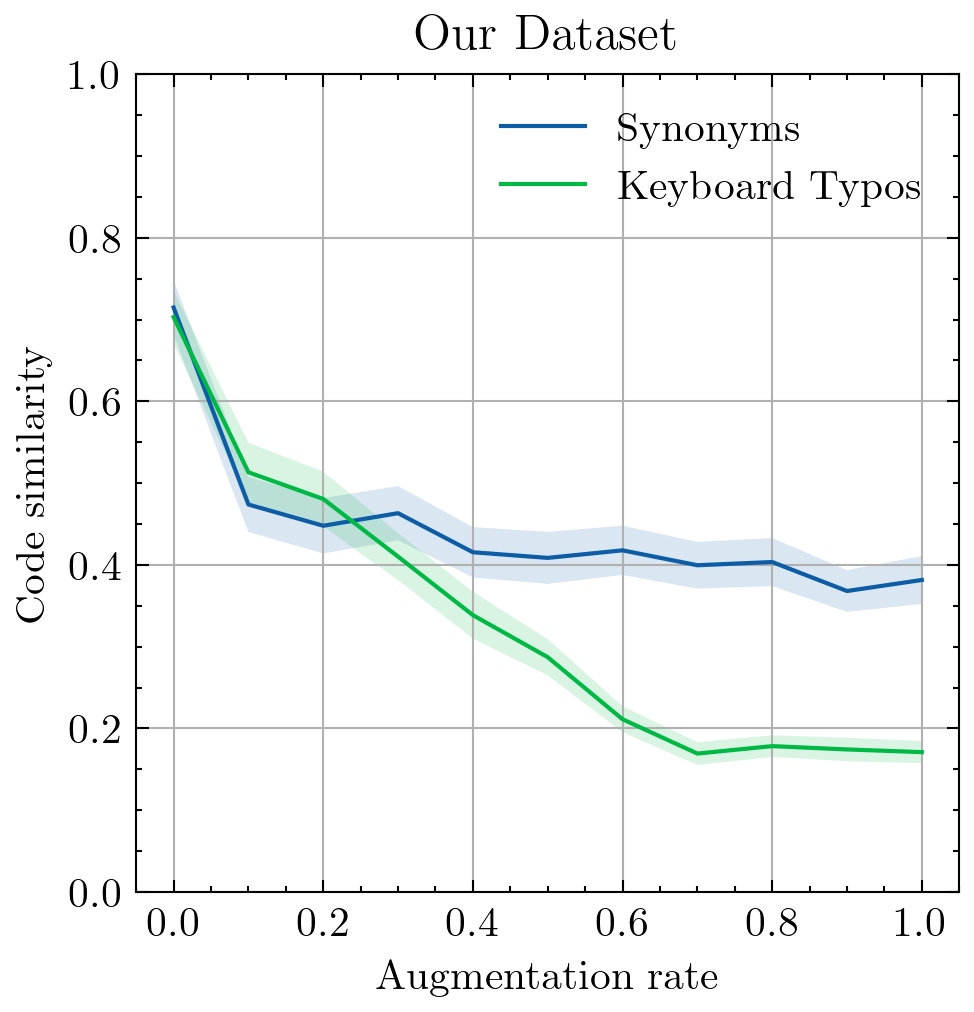

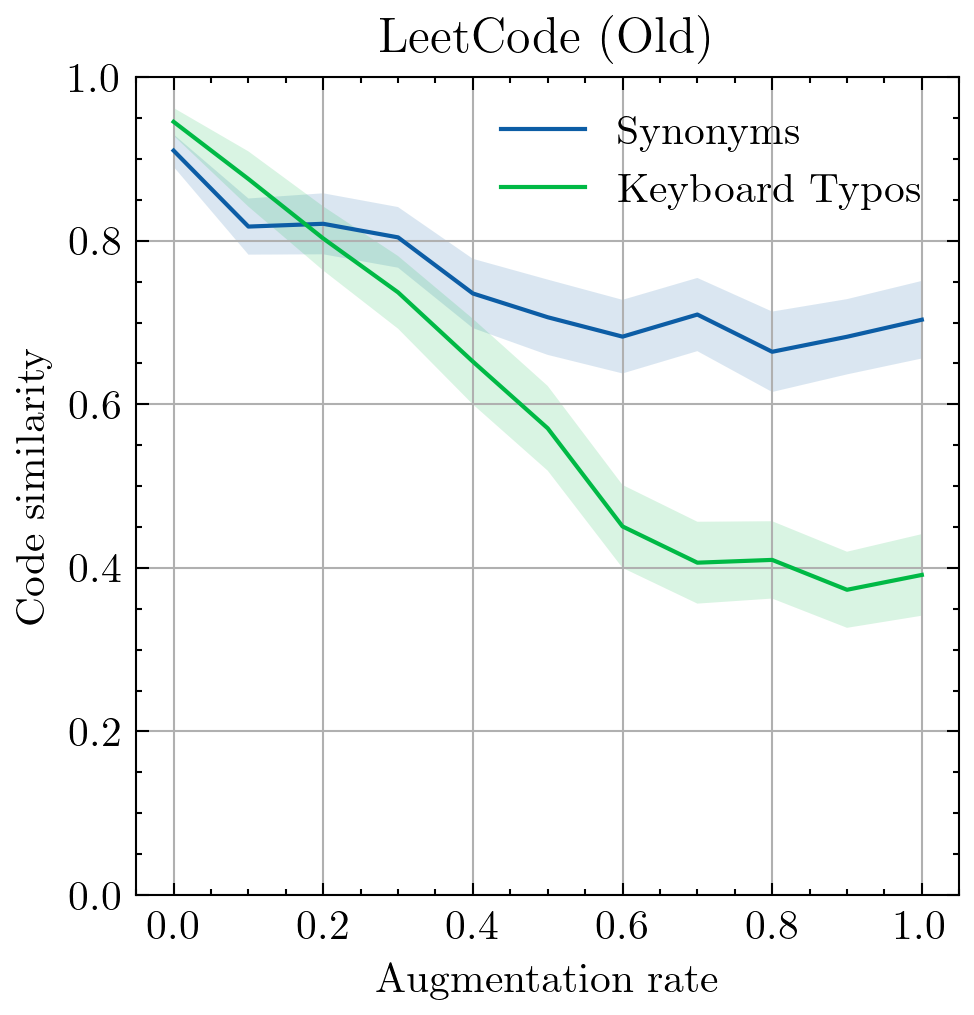

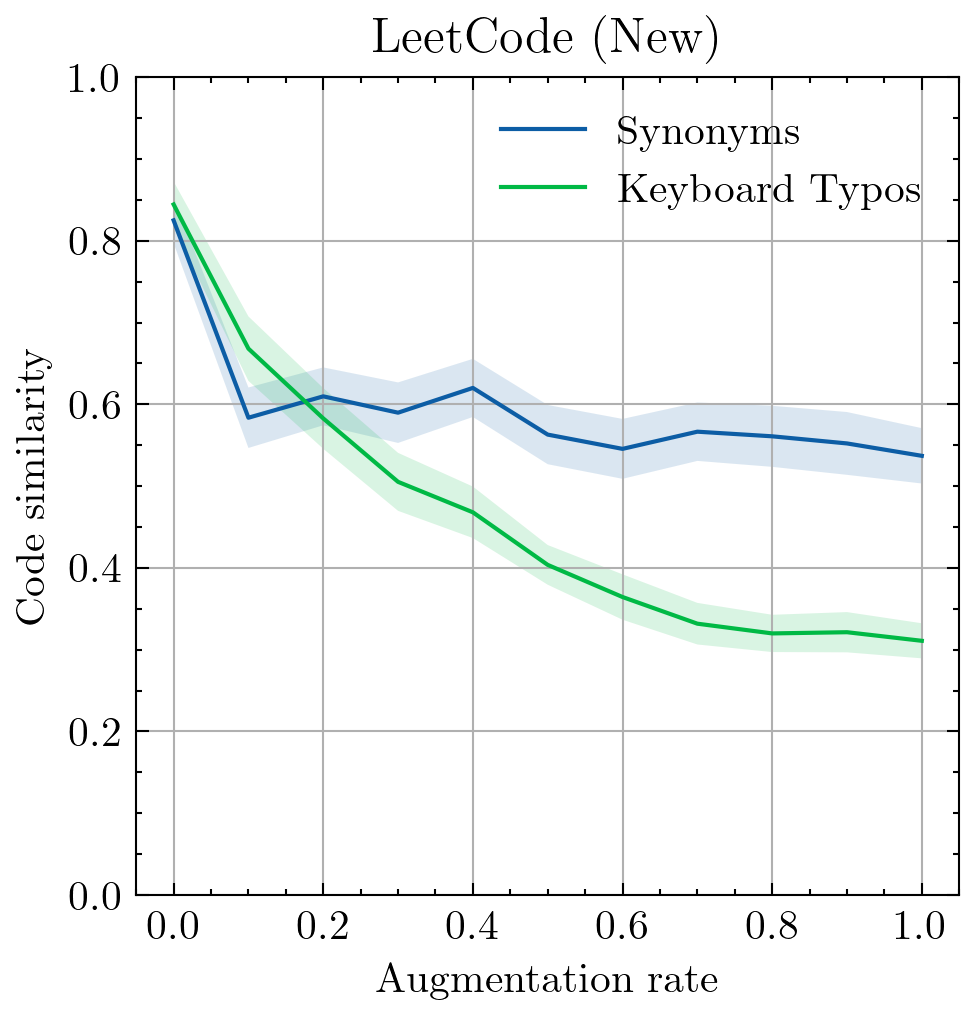

In [265]:
plot_all_datasets(df, "overall")

## Paraphrasing separately

In [268]:
headers = ["model", "dataset", "augmentation_rate", "tsed_score"]
all_data = []

for root, _, files in os.walk(metrics_dir):
    if "paraphrase" not in root:
        continue

    for file in files:
        if not file.endswith(".csv"):
            continue

        file_path = os.path.join(root, file)
        df = pd.read_csv(file_path)

        if df.empty or "augmentation_rate" not in df.columns:
            continue

        df["augmentation_rate"] = df["augmentation_rate"].astype(float)
        # skip all 0.05 steps
        # df = df[(df["augmentation_rate"] * 100).astype(int) % 10 == 0]
        df.sort_values("augmentation_rate", inplace=True)

        valid_rates = df["augmentation_rate"].value_counts()
        valid_rates = valid_rates[valid_rates == 5].index
        df = df[df["augmentation_rate"].isin(valid_rates)]
        df = df[df['tsed_score'].notna()]

        if df.empty:
            continue

        for (i, row) in df.iterrows():
            all_data.append([row["model"], row["dataset"], row["augmentation_rate"], row["tsed_score"]])

para_df = pd.DataFrame(all_data, columns=headers)

In [272]:
para_df

,model,dataset,augmentation_rate,tsed_score
0,gemini,ourdataset.json,0.0,0.803184
1,gemini,ourdataset.json,0.0,0.719927
2,gemini,ourdataset.json,0.0,0.719927
3,gemini,ourdataset.json,0.0,0.803184
4,gemini,ourdataset.json,0.0,0.803184
...,...,...,...,...
2067,llama,newleetcode.json,0.6,0.169044
2068,llama,newleetcode.json,0.6,0.277374
2069,llama,newleetcode.json,0.6,0.229374
2070,llama,newleetcode.json,0.6,0.297773


In [ ]:
for model in para_df["model"].unique().tolist():
    mm_df = para_df[para_df["model"] == model]
    
    means = df_to_show.groupby("augmentation_rate")[["tsed_score"]].mean()
    stds = df_to_show.groupby("augmentation_rate")[["tsed_score"]].std()
    ci = 1.96 * stds["tsed_score"] / len(means)
    plt.fill_between(means.index, means["tsed_score"] - ci, means["tsed_score"] + ci, alpha=0.15)
    plt.plot(means.index, means["tsed_score"], label=label)

    plot_with_ci(mm_df, label=model_names[model])

setup_figure(aug_names[method])
if save_label is not None:
    save_path = os.path.join("figures", f"{method}_{save_label}.png")
    plt.savefig(save_path, bbox_inches='tight')
plt.show()